# Oscilloscope - Waveform Visualization

This notebook demonstrates a digital oscilloscope displaying different wave types (sine, cosine, square, sawtooth, triangle) and frequencies using matplotlib.

Use the slider controls to adjust frequency and see how the waveforms change in real-time.

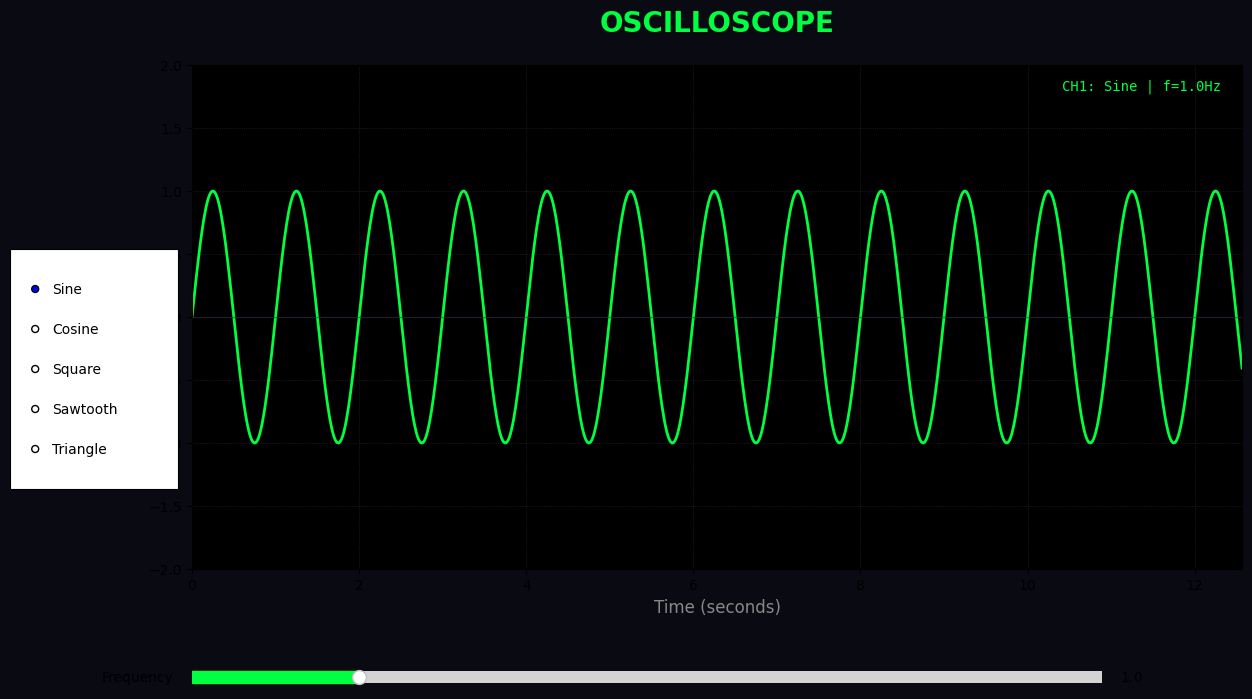

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, RadioButtons

# Set up the figure with a dark scope-like background
fig = plt.figure(figsize=(14, 8))
fig.patch.set_facecolor('#0a0a12')

# Create a main axis for the oscilloscope display
ax_main = fig.add_subplot(111)
fig.subplots_adjust(left=0.15, bottom=0.25)

# Time array
t = np.linspace(0, 4*np.pi, 1000)

# Wave functions
def sine_wave(t, freq):
    return np.sin(2 * np.pi * freq * t)

def cosine_wave(t, freq):
    return np.cos(2 * np.pi * freq * t)

def square_wave(t, freq):
    return np.sign(np.sin(2 * np.pi * freq * t))

def sawtooth_wave(t, freq):
    return 2 * (t * freq - np.floor(t * freq + 0.5))

def triangle_wave(t, freq):
    return 2 * np.abs(2 * (t * freq - np.floor(t * freq + 0.5))) - 1

# Wave dictionary
wave_dict = {
    'Sine': lambda t: sine_wave(t, 1),
    'Cosine': lambda t: cosine_wave(t, 1),
    'Square': lambda t: square_wave(t, 1),
    'Sawtooth': lambda t: sawtooth_wave(t, 1),
    'Triangle': lambda t: triangle_wave(t, 1)
}

# Plot initial waveform
line, = ax_main.plot(t, sine_wave(t, 1), color='#00ff41', linewidth=2)

# Add horizontal center line
ax_main.axhline(y=0, color='#333344', linestyle='-', linewidth=1, alpha=0.5)

# Style the axis
ax_main.set_facecolor('#000000')
ax_main.grid(True, color='#2a2a38', linestyle=':', linewidth=0.5)
ax_main.set_title('OSCILLOSCOPE', color='#00ff41', fontsize=20, weight='bold', y=1.05)
ax_main.set_xlabel('Time (seconds)', color='#888888', fontsize=12)
ax_main.set_ylabel('Amplitude', color='#888888', fontsize=12)
ax_main.set_ylim(-2, 2)
ax_main.set_xlim(0, 4*np.pi)

# Add status text
status_text = ax_main.text(0.98, 0.95, '', transform=ax_main.transAxes, 
                          color='#00ff41', fontsize=10, fontfamily='monospace',
                          ha='right')

# Color map for different waves
wave_colors = {
    'Sine': '#00ff41',
    'Cosine': '#ffaa00',
    'Square': '#ff0044',
    'Sawtooth': '#aa00ff',
    'Triangle': '#00aaff'
}

# Create slider for frequency control
ax_freq = fig.add_axes([0.15, 0.1, 0.65, 0.03])
freq_slider = Slider(ax_freq, 'Frequency', 0.1, 5.0, valinit=1.0, valstep=0.1, color='#00ff41')

# Create radio buttons for wave type selection
rax = plt.axes([0.02, 0.35, 0.12, 0.3])
radio = RadioButtons(rax, list(wave_dict.keys()), active=0)

def update_wave(type_name):
    freq = freq_slider.val
    new_y = wave_dict[type_name](t, freq)
    line.set_ydata(new_y)
    line.set_color(wave_colors[type_name])
    status_text.set_text(f'CH1: {type_name} | f={freq:.1f}Hz')
    fig.canvas.draw_idle()

def update_frequency(val):
    active_wave = radio.value_selected
    freq = val
    new_y = wave_dict[active_wave](t, freq)
    line.set_ydata(new_y)
    status_text.set_text(f'CH1: {active_wave} | f={freq:.1f}Hz')
    fig.canvas.draw_idle()

radio.on_clicked(update_wave)
freq_slider.on_changed(update_frequency)
status_text.set_text('CH1: Sine | f=1.0Hz')

plt.show()

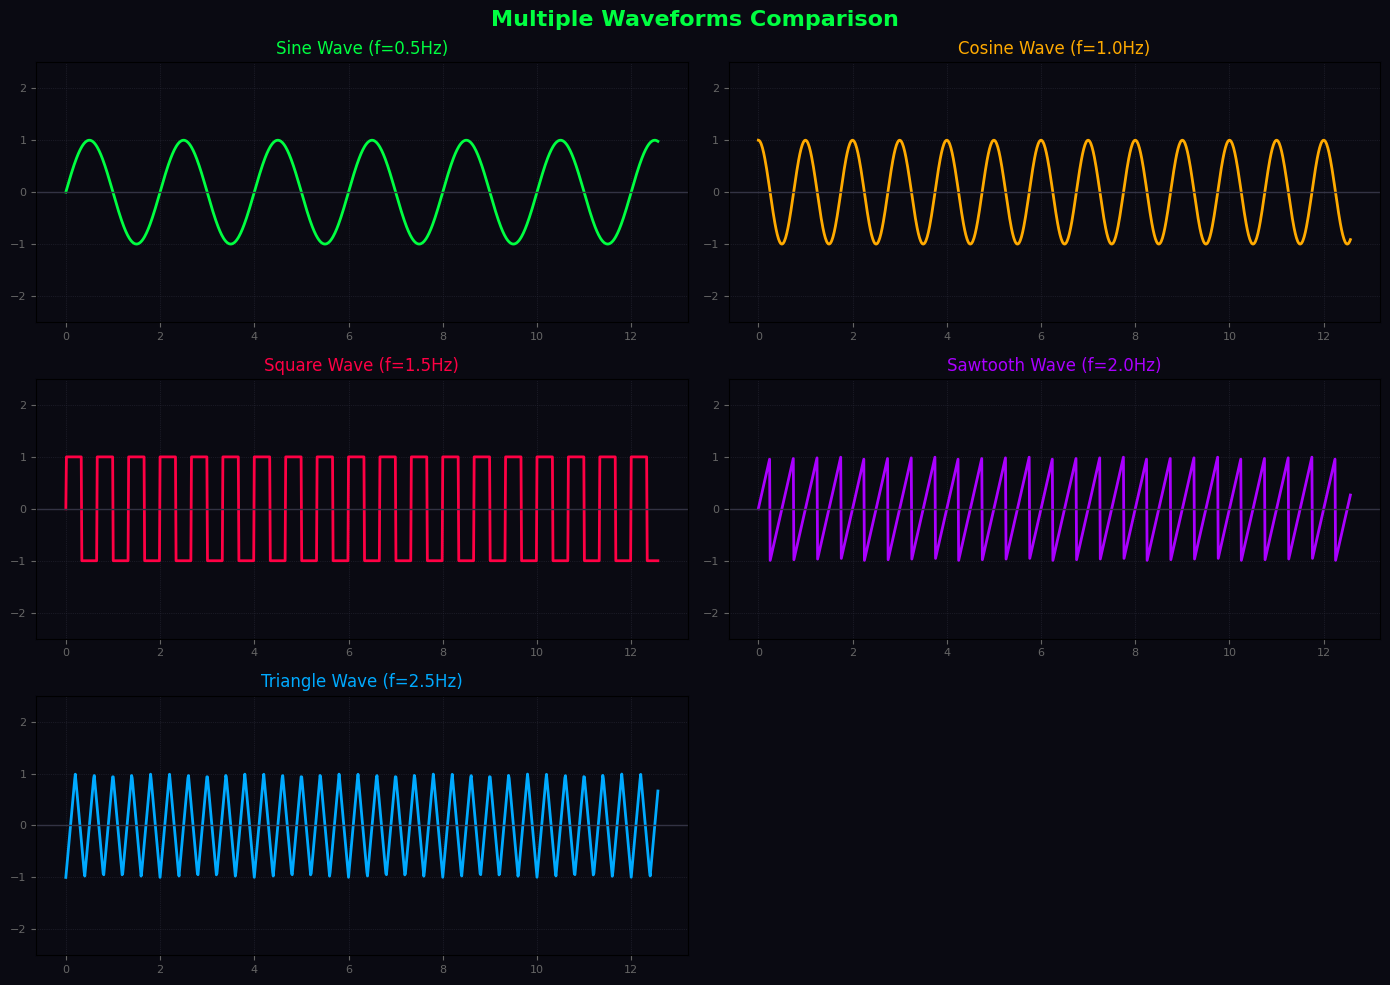

In [4]:
# Additional visualization: All waves at once

fig2, axes = plt.subplots(3, 2, figsize=(14, 10))
fig2.patch.set_facecolor('#0a0a12')

frequencies = [0.5, 1.0, 1.5, 2.0, 2.5]

for idx, (name, wave_fn) in enumerate(wave_dict.items()):
    ax = axes[idx // 2, idx % 2]
    freq = frequencies[idx]
    # Call lambda with correct arguments
    if name == 'Sine':
        y = sine_wave(t, freq)
    elif name == 'Cosine':
        y = cosine_wave(t, freq)
    elif name == 'Square':
        y = square_wave(t, freq)
    elif name == 'Sawtooth':
        y = sawtooth_wave(t, freq)
    elif name == 'Triangle':
        y = triangle_wave(t, freq)
    
    ax.plot(t, y, color=wave_colors[name], linewidth=2)
    ax.axhline(y=0, color='#333344', linestyle='-', linewidth=1)
    ax.set_facecolor('#0a0a12')
    ax.grid(True, color='#2a2a38', linestyle=':', linewidth=0.5)
    ax.set_title(f'{name} Wave (f={freq}Hz)', color=wave_colors[name], fontsize=12)
    ax.set_ylim(-2.5, 2.5)
    ax.tick_params(colors='#666666', labelsize=8)

# Remove extra subplot
axes[2, 1].set_visible(False)

plt.suptitle('Multiple Waveforms Comparison', color='#00ff41', fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

## Oscilloscope Controls

**Frequency Slider** (bottom): Adjusts the frequency of the displayed waveform from 0.1Hz to 5.0Hz

**Wave Type Selector** (left): Choose from:
- **Sine** - Smooth sinusoidal wave (green)
- **Cosine** - Phase-shifted sine wave (orange)
- **Square** - Digital-style rectangular wave (red)
- **Sawtooth** - Ramp-up waveform (purple)
- **Triangle** - Linear rise and fall (cyan)

---
*Created with Jupyter & agent-client-kernel*